In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\lenovo\Downloads\archive (8)\train.csv")


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [11]:
def get_season(month):
    if month in [6,7,8,9]:
        return "Monsoon"
    elif month in [10,11,12]:
        return "Winter"
    else:
        return "Summer"

df['Season'] = df['Order Date'].dt.month.apply(get_season)

In [12]:
print(df[['Order Date','Season']].head())

  Order Date   Season
0 2017-11-08   Winter
1 2017-11-08   Winter
2 2017-06-12  Monsoon
3 2016-10-11   Winter
4 2016-10-11   Winter


In [13]:
season_sales = df.groupby('Season')['Sales'].sum()

print(season_sales)

Season
Monsoon    748792.5510
Summer     641606.0565
Winter     871138.1752
Name: Sales, dtype: float64


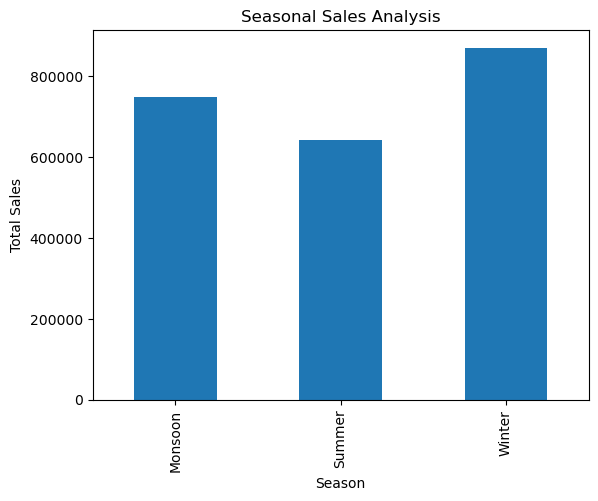

In [22]:
season_sales.plot(kind='bar')

plt.title("Seasonal Sales Analysis")
plt.xlabel("Season")
plt.ylabel("Total Sales")

plt.show()

In [14]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

print(top_products.head(10))

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


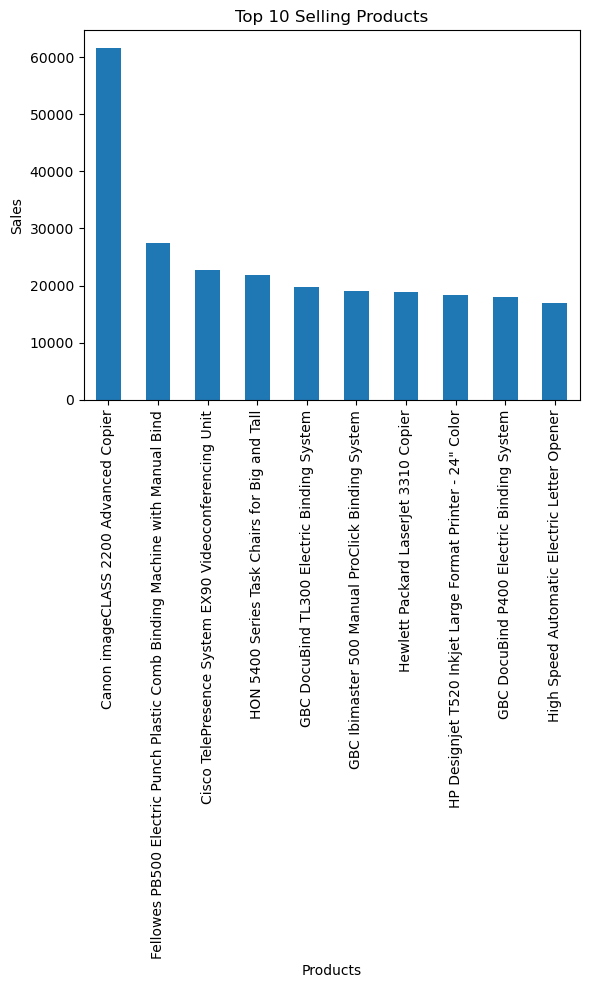

In [21]:
top_products.head(10).plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Sales")

plt.show()

In [16]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


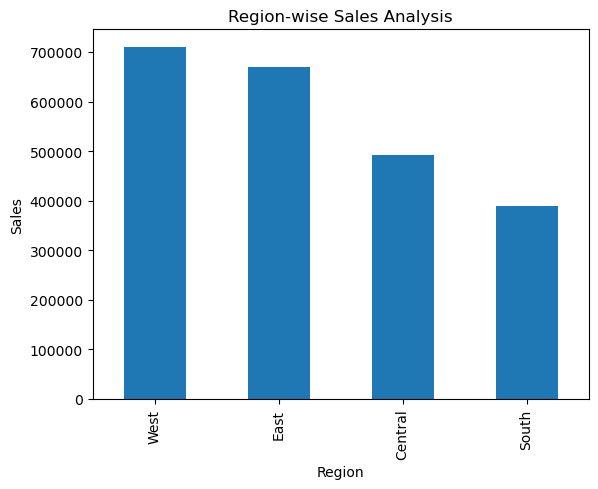

In [18]:
region_sales.plot(kind='bar')

plt.title("Region-wise Sales Analysis")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

Western region generated the highest sales revenue, while Southern region showed lower performance.

In [28]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

In [33]:
df['Month'] = df['Order Date'].dt.month_name()

In [30]:
print(df[['Order Date','Month']].head())

  Order Date     Month
0 2017-11-08  November
1 2017-11-08  November
2 2017-06-12      June
3 2016-10-11   October
4 2016-10-11   October


In [31]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


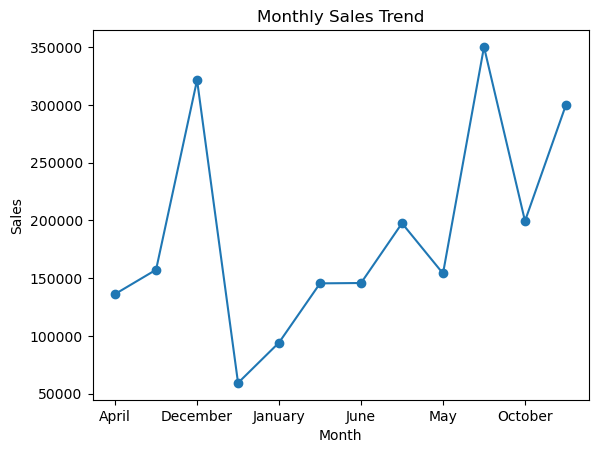

In [32]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [34]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


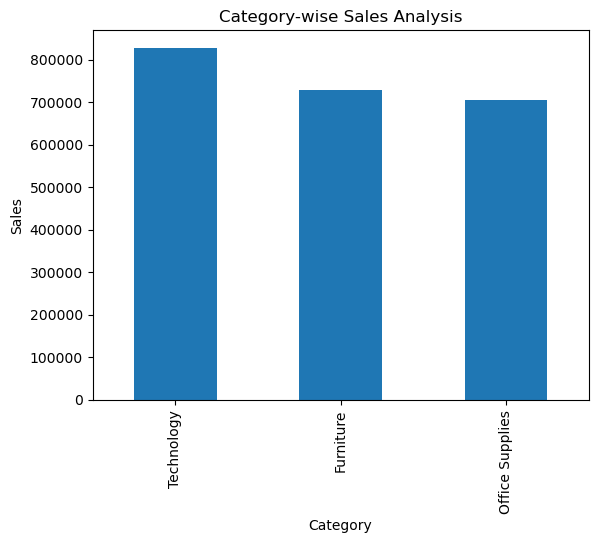

In [35]:

category_sales.plot(kind='bar')

plt.title("Category-wise Sales Analysis")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Technology category generated the highest sales revenue, indicating strong customer demand compared to other categories.

In [36]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

print(top_customers.head(10))

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


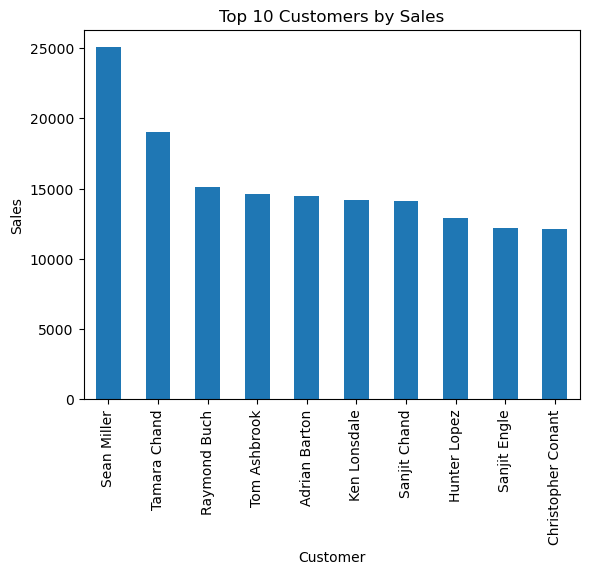

In [37]:

top_customers.head(10).plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.show()

A small group of customers contributed significantly to total revenue, indicating the importance of high-value customer retention.


In [38]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(sub_category_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


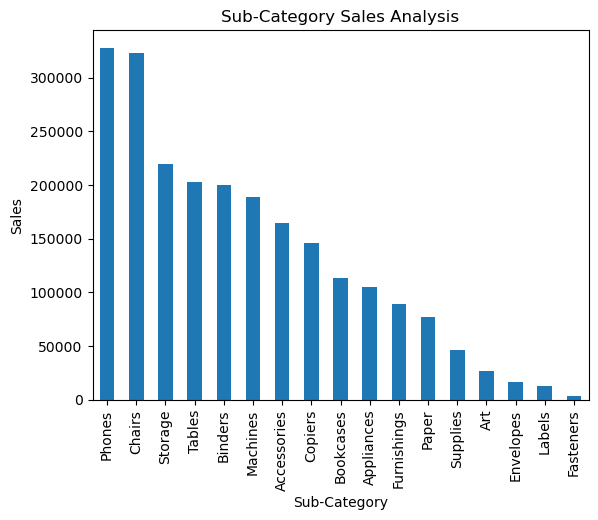

In [39]:
sub_category_sales.plot(kind='bar')

plt.title("Sub-Category Sales Analysis")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.show()

Phones and chairs generated the highest sales among all sub-categories, indicating strong customer demand in these segments.

In [41]:
df.to_csv("cleaned_data.csv", index=False)